In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


torch.set_num_threads(os.cpu_count() or 1)
torch.set_num_interop_threads(1)


RuntimeError: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads called

Available columns: ['averageInteractionsPerCrossing', 'p_Rhad1', 'p_Rhad', 'p_f3', 'p_weta2', 'p_Rphi', 'p_Reta', 'p_Eratio', 'p_f1', 'p_TRTPID']

Energy-related columns: ['pX_core57cellsEnergyCorrection', 'pX_maxEcell_energy', 'pX_neflowisolcoreConeEnergyCorrection', 'pX_topoetconecoreConeEnergyCorrection', 'p_Truth_Energy']
Electron-related columns: ['p_Truth_isElectron']
Epoch 1/25 - loss: 0.1353 - train_acc: 0.9580 - val_loss: 0.1177 - val_acc: 0.9566
Epoch 2/25 - loss: 0.1121 - train_acc: 0.9627 - val_loss: 0.1085 - val_acc: 0.9603
Epoch 3/25 - loss: 0.1054 - train_acc: 0.9648 - val_loss: 0.1027 - val_acc: 0.9624
Epoch 4/25 - loss: 0.1017 - train_acc: 0.9667 - val_loss: 0.0989 - val_acc: 0.9633
Epoch 5/25 - loss: 0.0985 - train_acc: 0.9672 - val_loss: 0.1001 - val_acc: 0.9632
Epoch 6/25 - loss: 0.0955 - train_acc: 0.9685 - val_loss: 0.0970 - val_acc: 0.9647
Epoch 7/25 - loss: 0.0934 - train_acc: 0.9690 - val_loss: 0.0985 - val_acc: 0.9638
Epoch 8/25 - loss: 0.0909 - train_acc: 0.9

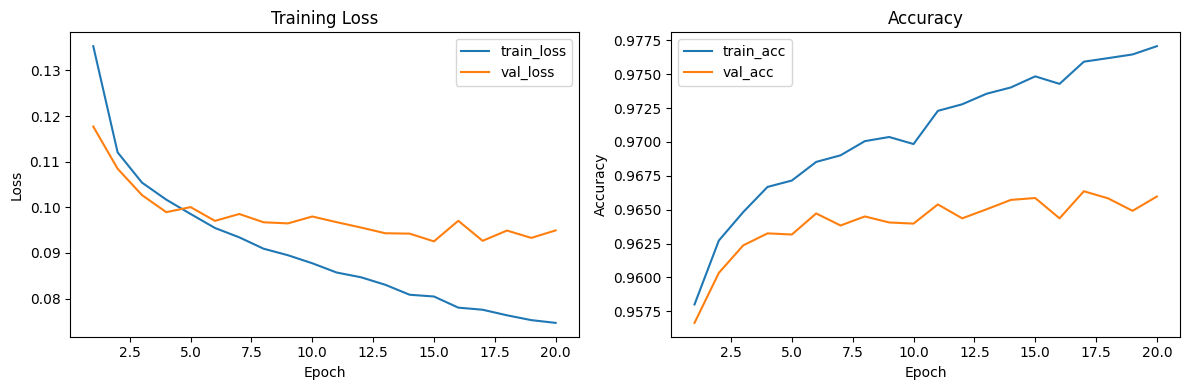

Top 15 Features and Their Importance:
                            feature  importance       std
20                      p_deltaEta1    0.046244  0.000914
9                          p_TRTPID    0.012250  0.000572
36                    pX_E_Lr1_MedG    0.009450  0.000511
10     p_numberOfInnermostPixelHits    0.008664  0.000557
2                            p_Rhad    0.007997  0.000619
18                        p_sigmad0    0.007942  0.000399
68                      pX_etcone20    0.007039  0.000550
17                             p_d0    0.004603  0.000339
42                   pX_MultiLepton    0.003272  0.000342
48   pX_core57cellsEnergyCorrection    0.003258  0.000302
19                        p_dPOverP    0.002853  0.000374
132                    pX_E7x11_Lr2    0.002797  0.000333
32                     pX_E_Lr0_HiG    0.002783  0.000473
30                      pX_E7x7_Lr2    0.002733  0.000269
69                      pX_etcone30    0.002497  0.000314


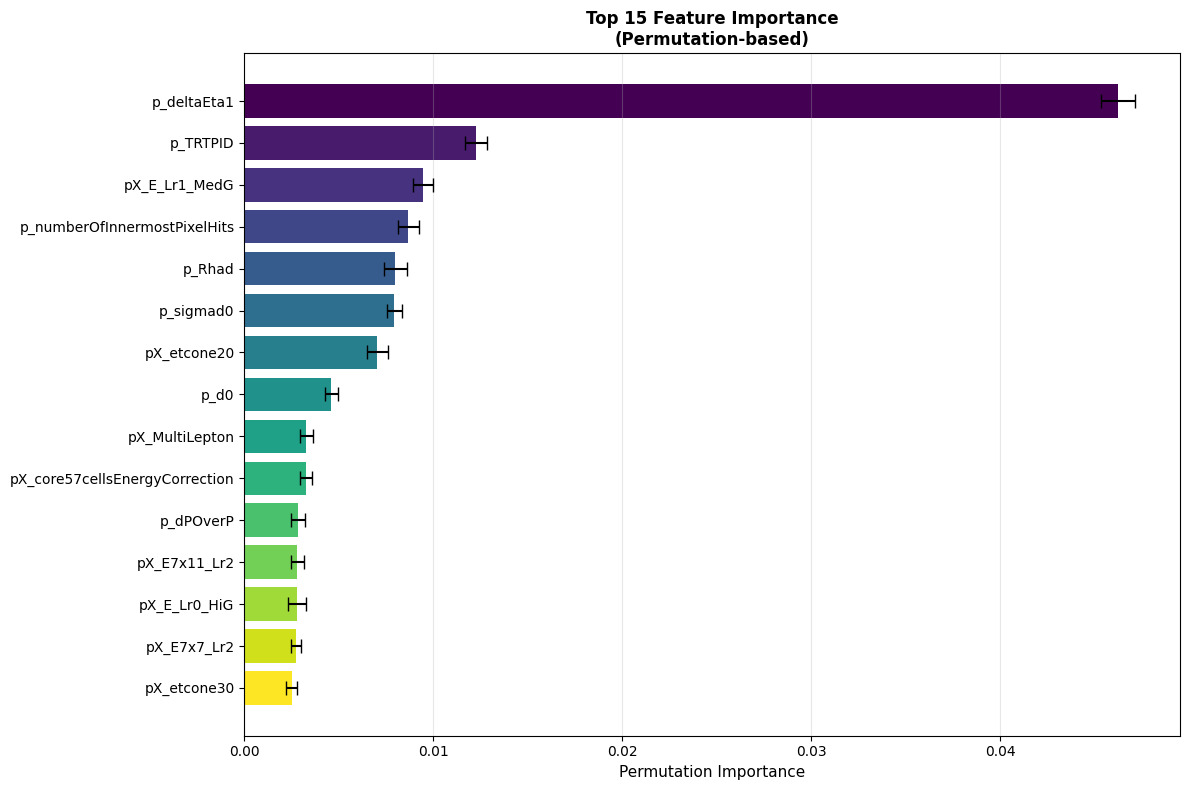

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
import copy

# PyTorch MLP wrapped as sklearn-compatible classifier with training history
class PyTorchNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_size=64, dropout=0.2, learning_rate=0.001, epochs=50, batch_size=32, random_state=42):
        self.hidden_size = hidden_size
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.model = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    def _build_model(self, input_dim):
        return nn.Sequential(
            nn.Linear(input_dim, self.hidden_size),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(self.hidden_size, self.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(self.hidden_size // 2, 1),
            nn.Sigmoid()
        ).to(self.device)
    
    def fit(self, X, y, X_val=None, y_val=None, verbose=False, early_stopping=True, patience=5):
        torch.manual_seed(self.random_state)
        X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
        y_tensor = torch.FloatTensor(y.values if hasattr(y, 'values') else y).reshape(-1, 1).to(self.device)
        
        if self.model is None:
            self.model = self._build_model(X_tensor.shape[1])
        
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        criterion = nn.BCELoss()
        
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        best_val_loss = np.inf
        best_epoch = -1
        epochs_no_improve = 0
        best_state = None
        
        for epoch in range(self.epochs):
            epoch_loss = 0.0
            self.model.train()
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                output = self.model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * X_batch.size(0)
            epoch_loss /= len(loader.dataset)
            # Compute training accuracy on full training set
            self.model.eval()
            with torch.no_grad():
                train_outputs = self.model(X_tensor).cpu().numpy().flatten()
                train_preds = (train_outputs > 0.5).astype(int)
                y_true = y_tensor.cpu().numpy().flatten()
                train_acc = np.mean(train_preds == y_true)
            val_loss = None
            val_acc = None
            if X_val is not None and y_val is not None:
                X_val_tensor = torch.FloatTensor(X_val.values if hasattr(X_val, 'values') else X_val).to(self.device)
                y_val_tensor = torch.FloatTensor(y_val.values if hasattr(y_val, 'values') else y_val).reshape(-1, 1).to(self.device)
                with torch.no_grad():
                    val_outputs = self.model(X_val_tensor)
                    val_loss = criterion(val_outputs, y_val_tensor).item()
                    val_preds = (val_outputs.cpu().numpy().flatten() > 0.5).astype(int)
                    val_acc = np.mean(val_preds == (y_val.values if hasattr(y_val, 'values') else y_val))
            # Record history
            self.history['train_loss'].append(epoch_loss)
            self.history['train_acc'].append(train_acc)
            if val_loss is not None:
                self.history['val_loss'].append(val_loss)
                self.history['val_acc'].append(val_acc)

            # Early stopping logic
            if early_stopping and val_loss is not None:
                if val_loss + 1e-6 < best_val_loss:
                    best_val_loss = val_loss
                    best_epoch = epoch
                    epochs_no_improve = 0
                    best_state = copy.deepcopy(self.model.state_dict())
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= patience:
                    if verbose:
                        print(f"Early stopping: no improvement after {patience} epochs. Restoring best model from epoch {best_epoch+1}.")
                    if best_state is not None:
                        self.model.load_state_dict(best_state)
                    break

            if verbose and (epoch % max(1, self.epochs // 50) == 0 or epoch == self.epochs - 1):
                msg = f"Epoch {epoch+1}/{self.epochs} - loss: {epoch_loss:.4f} - train_acc: {train_acc:.4f}"
                if val_loss is not None:
                    msg += f" - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
                print(msg)
        return self
    
    def predict_proba(self, X):
        X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
        self.model.eval()
        with torch.no_grad():
            proba_class1 = self.model(X_tensor).cpu().numpy().flatten()
        proba_class0 = 1 - proba_class1
        return np.column_stack([proba_class0, proba_class1])
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = y.values if hasattr(y, 'values') else y
        return np.mean(y_pred == y_true)


# --- Data Loading and Initial Prep ---
reg_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')

# Check column names
print("Available columns:", reg_train_data.columns.tolist()[:10])
print("\nEnergy-related columns:", [col for col in reg_train_data.columns if 'energy' in col.lower()])
print("Electron-related columns:", [col for col in reg_train_data.columns if 'electron' in col.lower()])


# Load data
class_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')
class_test_data = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')

# Prepare features and target
target = class_train_data['p_Truth_isElectron']
variables = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])

# Normalize features
scaler = StandardScaler()
variables_scaled = pd.DataFrame(
    scaler.fit_transform(variables),
    columns=variables.columns,
    index=variables.index
)
# Normalize features
scaler = StandardScaler()
variables_scaled = pd.DataFrame(
    scaler.fit_transform(variables),
    columns=variables.columns,
    index=variables.index
)

# Split into train/validation for calculating importance on unseen data
X_train, X_val, y_train, y_val = train_test_split(
    variables_scaled, target, test_size=0.2, random_state=42, stratify=target
)

# Train PyTorch model
model = PyTorchNNClassifier(
    hidden_size=128,
    dropout=0.1,
    learning_rate=0.0005,
    epochs=25,
    batch_size=32,
    random_state=42
)

model.fit(X_train, y_train, X_val=X_val, y_val=y_val, verbose=True)

# Evaluate on validation set
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)
print(f'Train accuracy: {train_score:.4f}')
print(f'Validation accuracy: {val_score:.4f}')

# Plot training history (loss and accuracy) if available
if hasattr(model, 'history') and len(model.history['train_loss']) > 0:
    epochs = range(1, len(model.history['train_loss']) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, model.history['train_loss'], label='train_loss')
    if len(model.history.get('val_loss', [])) > 0:
        plt.plot(epochs, model.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training Loss')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, model.history['train_acc'], label='train_acc')
    if len(model.history.get('val_acc', [])) > 0:
        plt.plot(epochs, model.history['val_acc'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.tight_layout()
    plt.show()

# Calculate permutation importance on validation set
perm_importance = permutation_importance(
    model, X_val, y_val,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

# Create results dataframe
importance_df = pd.DataFrame({
    'feature': variables.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Bar plot
top_n = 15
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=colors, capsize=5)
plt.xlabel('Permutation Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importance\n(Permutation-based)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

#Print top 15 features and their importance
print("Top 15 Features and Their Importance:")
print(importance_df.head(15))


In [ ]:
print("Top 15 Features and Their Importance:")
print(importance_df.head(15))

Top 15 Features and Their Importance:
                           feature  importance  std
0   averageInteractionsPerCrossing         0.0  0.0
1                          p_Rhad1         0.0  0.0
2                           p_Rhad         0.0  0.0
3                             p_f3         0.0  0.0
4                          p_weta2         0.0  0.0
5                           p_Rphi         0.0  0.0
6                           p_Reta         0.0  0.0
7                         p_Eratio         0.0  0.0
8                             p_f1         0.0  0.0
9                         p_TRTPID         0.0  0.0
10    p_numberOfInnermostPixelHits         0.0  0.0
11             p_numberOfPixelHits         0.0  0.0
12               p_numberOfSCTHits         0.0  0.0
13               p_numberOfTRTHits         0.0  0.0
14             p_TRTTrackOccupancy         0.0  0.0


Epoch 1/30 - loss: 0.1424 - train_acc: 0.9541 - val_loss: 0.1258 - val_acc: 0.9531
Epoch 2/30 - loss: 0.1193 - train_acc: 0.9587 - val_loss: 0.1142 - val_acc: 0.9570
Epoch 3/30 - loss: 0.1113 - train_acc: 0.9603 - val_loss: 0.1102 - val_acc: 0.9588
Epoch 4/30 - loss: 0.1062 - train_acc: 0.9613 - val_loss: 0.1058 - val_acc: 0.9594
Epoch 5/30 - loss: 0.1032 - train_acc: 0.9626 - val_loss: 0.1040 - val_acc: 0.9607
Epoch 6/30 - loss: 0.1010 - train_acc: 0.9621 - val_loss: 0.1052 - val_acc: 0.9602
Epoch 7/30 - loss: 0.0992 - train_acc: 0.9640 - val_loss: 0.1004 - val_acc: 0.9616
Epoch 8/30 - loss: 0.0979 - train_acc: 0.9640 - val_loss: 0.0993 - val_acc: 0.9616
Epoch 9/30 - loss: 0.0971 - train_acc: 0.9647 - val_loss: 0.0978 - val_acc: 0.9621
Epoch 10/30 - loss: 0.0964 - train_acc: 0.9650 - val_loss: 0.0980 - val_acc: 0.9623
Epoch 11/30 - loss: 0.0954 - train_acc: 0.9649 - val_loss: 0.0998 - val_acc: 0.9623
Epoch 12/30 - loss: 0.0952 - train_acc: 0.9646 - val_loss: 0.0993 - val_acc: 0.9620
E

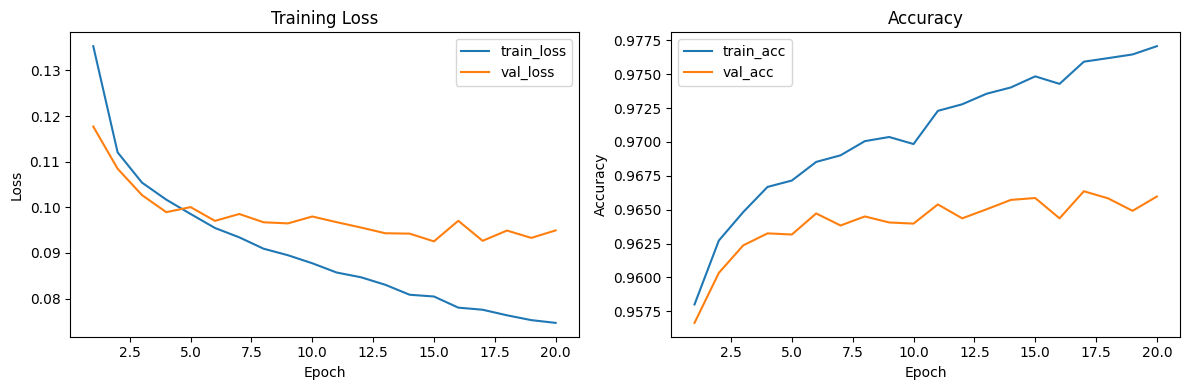

In [ ]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = PyTorchNNClassifier(
    hidden_size=128,
    dropout=0.1,
    learning_rate=0.0005,
    epochs=30,
    batch_size=32,
    random_state=42
)

model_top.fit(X_train_top, y_train, X_val_top, y_val, verbose = True)
train_score_top = model_top.score(X_train_top, y_train)
val_score_top = model_top.score(X_val_top, y_val)

print(f'Train accuracy with top features: {train_score_top:.4f}')
print(f'Validation accuracy with top features: {val_score_top:.4f}')


# Plot training history (loss and accuracy) if available
if hasattr(model_top, 'history') and len(model_top.history['train_loss']) > 0:
    epochs = range(1, len(model.history['train_loss']) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, model.history['train_loss'], label='train_loss')
    if len(model.history.get('val_loss', [])) > 0:
        plt.plot(epochs, model.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training Loss')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, model.history['train_acc'], label='train_acc')
    if len(model.history.get('val_acc', [])) > 0:
        plt.plot(epochs, model.history['val_acc'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.tight_layout()
    plt.show()

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter tuning for PyTorch NN on the reduced 15-feature set
param_distributions = {
    'hidden_size': [64, 128, 256],
    'dropout': uniform(0.1, 0.4),
    'learning_rate': uniform(0.0001, 0.01),
    'epochs': randint(30, 100),
    'batch_size': [16, 32, 64]
}

random_search = RandomizedSearchCV(
    estimator=PyTorchNNClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_top, y_train)

print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after tuning: {val_score_tuned:.4f}')



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV score: 0.9637
Best parameters: {'batch_size': 16, 'dropout': np.float64(0.1624074561769746), 'epochs': 53, 'hidden_size': 256, 'learning_rate': np.float64(0.0003058449429580245)}
Validation accuracy after tuning: 0.9624


In [11]:
# Compute log loss, relative MAE (safe), and total parameter count for PyTorch classifier
from sklearn.metrics import log_loss, mean_absolute_error
import numpy as np

# Predicted probabilities for class 1 on validation set
probs_val = best_model.predict_proba(X_val_top)
proba_pos = probs_val[:, 1]

# Log loss
try:
    val_logloss = log_loss(y_val, probs_val)
except Exception as e:
    val_logloss = None
    print('Could not compute log loss:', e)

# Relative MAE: compute |P - T| / max(T, eps) with small eps to avoid div by zero
y_val_arr = np.array(y_val if hasattr(y_val, 'values') else y_val).flatten()
eps = 1e-8
if np.any(y_val_arr == 0):
    # warn: relative metric may be unstable when true labels contain zeros
    print('Warning: some true labels are zero; relative MAE computed with eps to avoid division by zero')
rel_mae = np.mean(np.abs((proba_pos - y_val_arr) / np.maximum(y_val_arr, eps)))

# Parameter count (trainable)
param_count = None
try:
    torch_model = best_model.model
    param_count = sum(p.numel() for p in torch_model.parameters() if p.requires_grad)
except Exception as e:
    print('Could not extract PyTorch model parameters:', e)

print(f'Validation log loss: {val_logloss}')
print(f'Relative MAE (validation, |P-T|/T): {rel_mae:.6f}')
print(f'Total trainable parameters (PyTorch classifier): {param_count:,}')

Validation log loss: 0.45082243140095185
Relative MAE (validation, |P-T|/T): 3252677.426457
Total trainable parameters (PyTorch classifier): 37,121


In [10]:
from pathlib import Path

# Load test data, normalize with the training scaler, and extract top features
test_data_raw = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')
test_data_scaled = pd.DataFrame(
    scaler.transform(test_data_raw),
    columns=test_data_raw.columns
)

X_full_top = variables[top_feature_names]
best_model.fit(X_full_top, target)


X_test = test_data_scaled[top_feature_names]

# Get probability predictions for class 1 (electron)
test_predictions = best_model.predict_proba(X_test)[:, 1]

# Define output paths and filenames
solution_name = "PyTorch"
name = "BenjaminSiddique"
output_dir = Path('../Classification/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Classification_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Classification_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")